In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore') 

# LOADING THE LABELED DATA

try:
    df = pd.read_excel('labeled_master_dataset.xlsx')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'labeled_master_dataset.xlsx' not found.")
    exit()

# SEPARATING FEATURES (X) AND TARGET (y)
y = df['BPL_Target']

# Identifying direct income/threshold columns to drop (preventing Target Leakage)
income_cols = [col for col in df.columns if col.startswith('in') and any(char.isdigit() for char in col) or col.startswith('incometaxthreshold_')]

# Metadata columns to drop (Added Property_ID and Image_Name here)
metadata_cols = ['hasfamilyid', 'BPL_Target', 'district', 'blocktown', 'wardvillage', 'r_u', 'familyRange', 'Property_ID', 'Image_Name', 'Image_Context']

# Noisy proxy columns to drop 
noisy_cols = ['is_Child', 'is_Housewife', 'is_Senior Citizen', 'is_Student', 'is_Farmer', 'is_Labour', 'is_Pensioner/Retired']

cols_to_drop = metadata_cols + noisy_cols + income_cols 

# Dropping the columns to isolate the true proxy features
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Failsafe: Ensuring only numeric columns remain for scikit-learn
X = X.select_dtypes(include=['int64', 'float64'])

print(f"Total features selected for training: {X.shape[1]}")


# 3. STRATIFYING TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} families")
print(f"Testing set size: {X_test.shape[0]} families")

# BUILDING THE BALANCED PIPELINE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='linear', random_state=42))
])

# STRATIFIED CROSS-VALIDATION
print("\n--- Running 5-Fold Stratified Cross-Validation ---")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(pipeline, X_train, y_train, cv=cv_strategy, scoring=['f1_macro', 'accuracy'])

mean_f1 = np.mean(cv_results['test_f1_macro'])
std_f1 = np.std(cv_results['test_f1_macro'])
print(f"Cross-Validation Macro F1-Score: {mean_f1:.4f} (± {std_f1:.4f})")
if std_f1 > 0.1:
    print("Note: High standard deviation indicates the model's performance fluctuates depending on the data slice.")

# FINAL TRAINING & EVALUATION
print("\n--- Final Model Evaluation on Unseen Test Data ---")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-BPL (0)', 'BPL (1)']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (Correct Non-BPL): {cm[0][0]}")
print(f"False Positives (Fraudulent BPL Guesses): {cm[0][1]}")
print(f"False Negatives (Missed BPL Families): {cm[1][0]}")
print(f"True Positives (Correct BPL): {cm[1][1]}")

Dataset loaded successfully.
Total features selected for training: 60
Training set size: 1840 families
Testing set size: 461 families

--- Running 5-Fold Stratified Cross-Validation ---
Cross-Validation Macro F1-Score: 0.9669 (± 0.0047)

--- Final Model Evaluation on Unseen Test Data ---

Classification Report:
              precision    recall  f1-score   support

 Non-BPL (0)       0.99      1.00      1.00       383
     BPL (1)       1.00      0.97      0.99        78

    accuracy                           1.00       461
   macro avg       1.00      0.99      0.99       461
weighted avg       1.00      1.00      1.00       461

Confusion Matrix:
True Negatives (Correct Non-BPL): 383
False Positives (Fraudulent BPL Guesses): 0
False Negatives (Missed BPL Families): 2
True Positives (Correct BPL): 76


In [2]:
import joblib

# EXPORTING THE MODEL FOR PRODUCTION

model_filename = '3rd_pipeline.joblib'
joblib.dump(pipeline, model_filename)

print(f"\n🚀 Model successfully saved as '{model_filename}'!")
print("This file contains the scaled weights and is ready for production use.")


🚀 Model successfully saved as '3rd_pipeline.joblib'!
This file contains the scaled weights and is ready for production use.


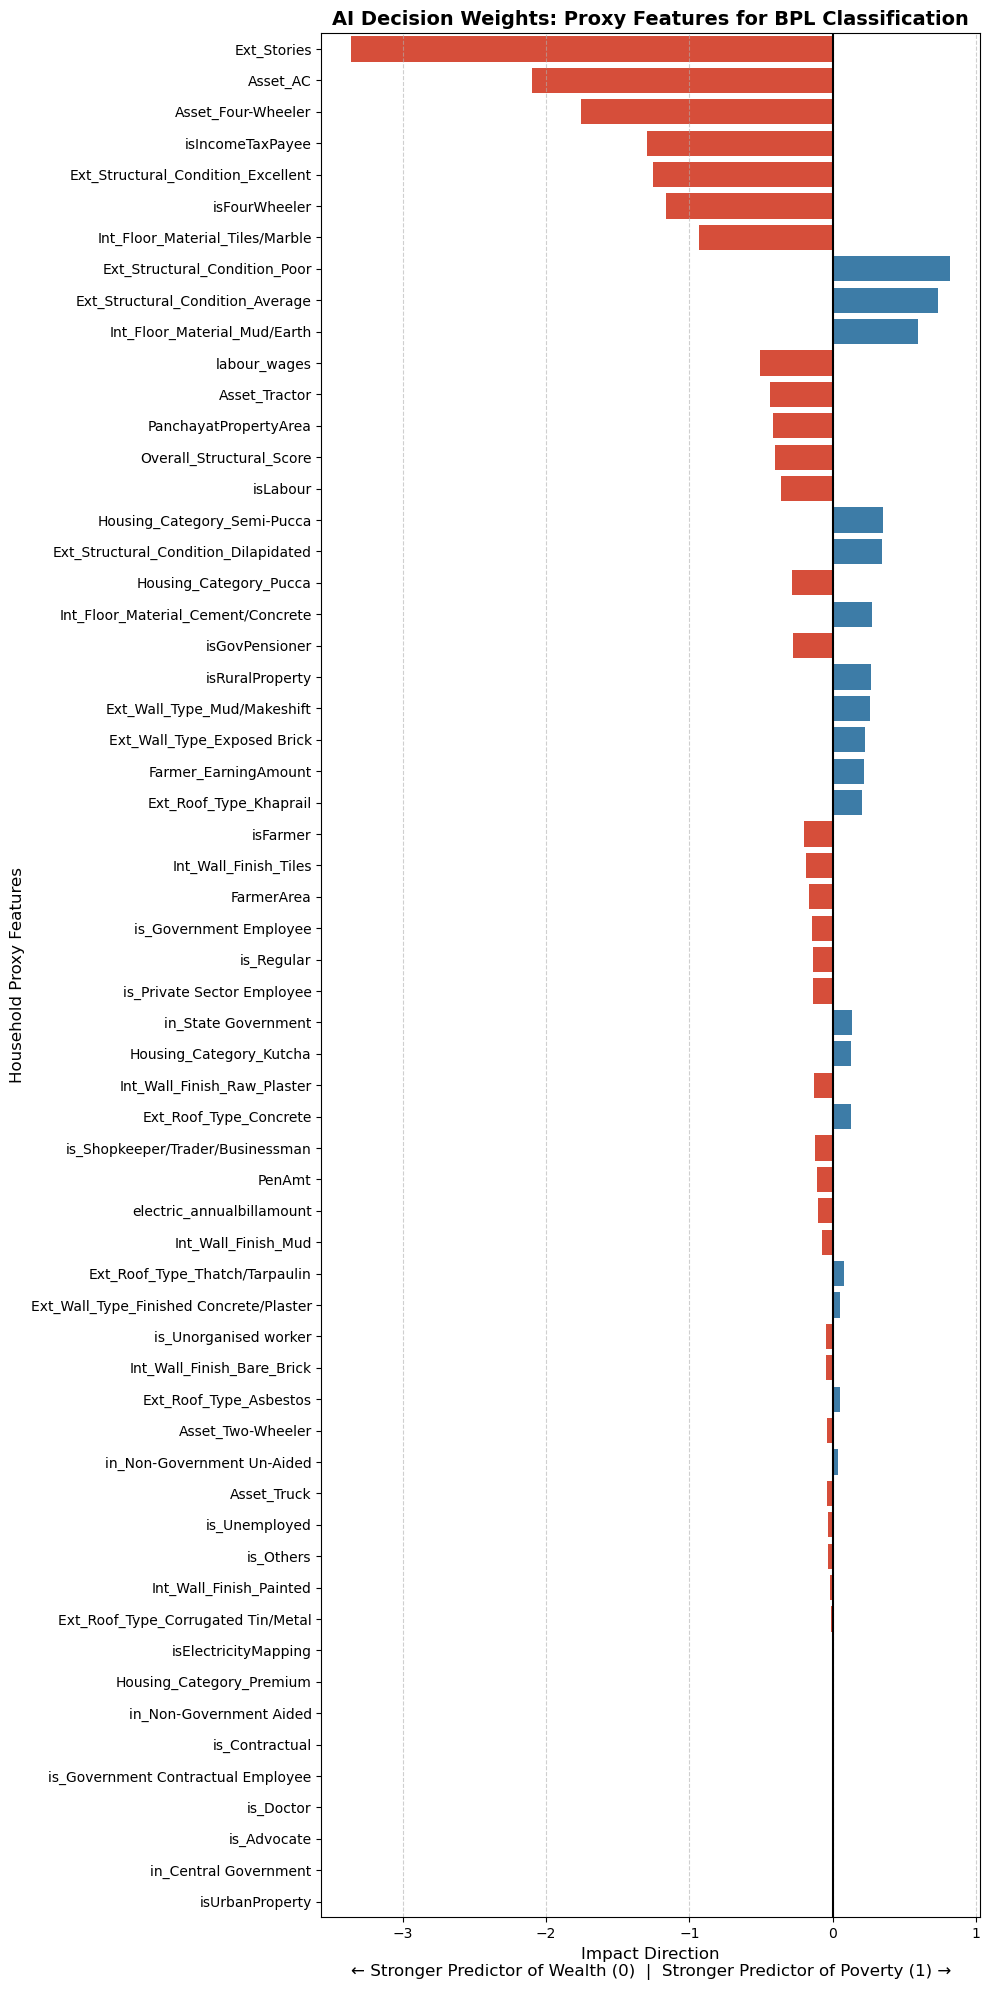


--- Top 5 Most Impactful Features ---
                           Feature  Importance
                       Ext_Stories   -3.360694
                          Asset_AC   -2.101972
                Asset_Four-Wheeler   -1.757459
                  isIncomeTaxPayee   -1.296614
Ext_Structural_Condition_Excellent   -1.252015


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# EXTRACTING WEIGHTS FROM THE PIPELINE
# Digging into the pipeline to get the trained Logistic Regression algorithm
classifier = pipeline.named_steps['classifier']

# Getting the coefficients (the mathematical weights it assigned to each column)
coefficients = classifier.coef_[0]
feature_names = X_train.columns

# BUILDING A SORTED DATAFRAME
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Creating an absolute value column so we can sort by the strongest impact (regardless of direction)
feature_importance_df['Absolute_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Importance', ascending=False)

# PLOTING THE VISUALIZATION
plt.figure(figsize=(10, 20))

# Color code: Blue = pushes toward BPL (1), Red = pushes toward Non-BPL (0)
colors = np.where(feature_importance_df['Importance'] > 0, '#2c7fb8', '#f03b20')

sns.barplot(
    data=feature_importance_df, 
    x='Importance', 
    y='Feature', 
    palette=colors,
    hue='Feature',
    legend=False
)

plt.title('AI Decision Weights: Proxy Features for BPL Classification', fontsize=14, fontweight='bold')
plt.xlabel('Impact Direction\n← Stronger Predictor of Wealth (0)  |  Stronger Predictor of Poverty (1) →', fontsize=12)
plt.ylabel('Household Proxy Features', fontsize=12)

# Drawing a black line at zero for clarity
plt.axvline(0, color='black', linewidth=1.5)  
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Saving the chart so it can be inserted directly into our project report!
plt.savefig('Feature_Importances_Chart.png', dpi=300)
plt.show()


# PRINTING SUMMARY FOR TERMINAL
print("\n--- Top 5 Most Impactful Features ---")
print(feature_importance_df[['Feature', 'Importance']].head(5).to_string(index=False))

Background dataset has 1840 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1840 when initializing the masker.



--- Starting SHAP Error Analysis ---
Images will be saved to the 'SHAP' folder.
Total mistakes isolated: 2
  -> False Positives (Guessed BPL, Actually Non-BPL): 0
  -> False Negatives (Guessed Non-BPL, Actually BPL): 2

Calculating SHAP values for the mistakes...


PermutationExplainer explainer: 3it [00:17,  8.68s/it]                                                                 



Visualizing 2 FALSE NEGATIVE(S)...


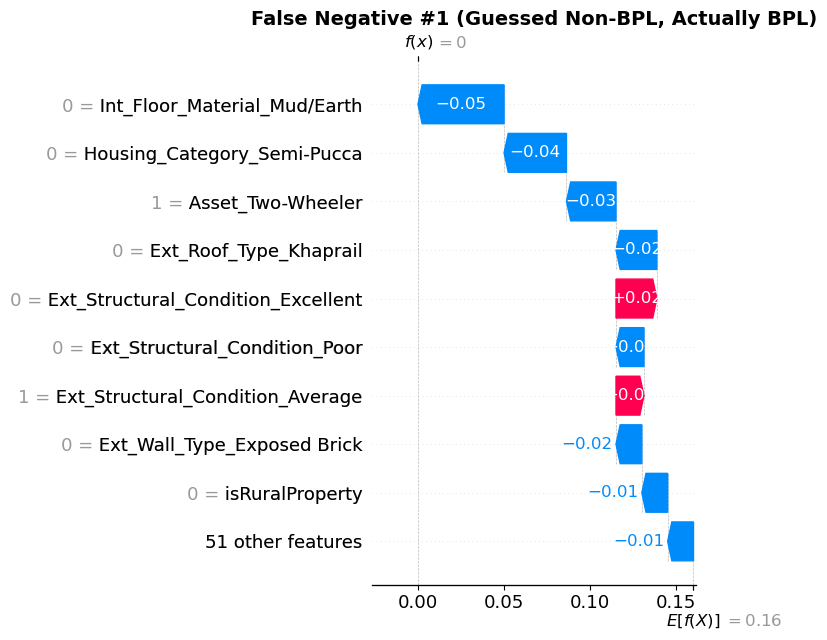

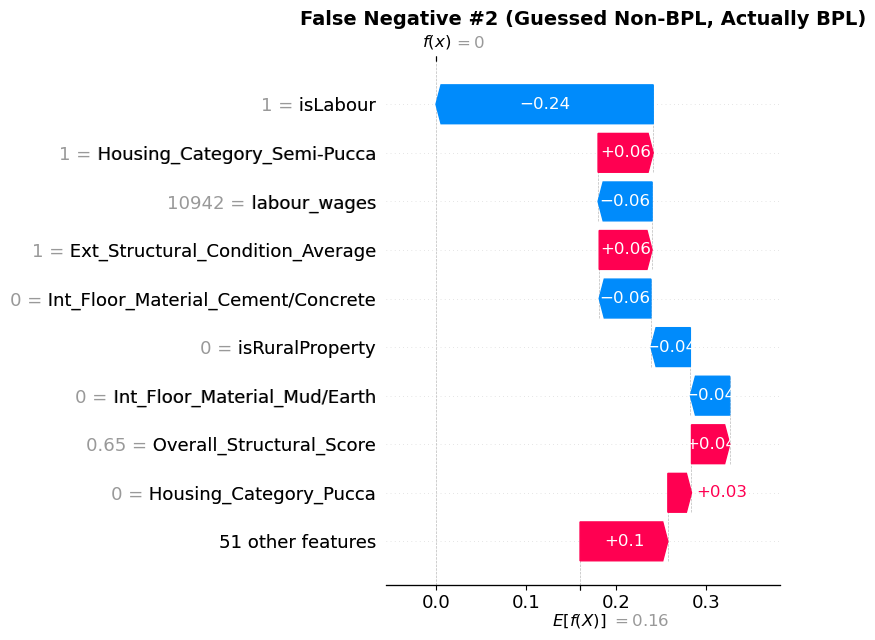

In [4]:
import shap
import matplotlib.pyplot as plt
import os

# SHAP ERROR ANALYSIS PIPELINE
print("\n--- Starting SHAP Error Analysis ---")

# CREATING THE SHAP DIRECTORY
# This creates a folder named 'SHAP' in your current directory. 
# exist_ok=True ensures it won't crash if the folder already exists.
output_dir = 'SHAP'
os.makedirs(output_dir, exist_ok=True)
print(f"Images will be saved to the '{output_dir}' folder.")

# ISOLATING THE MISTAKES
# Creating a copy of the test set and adding the actual and predicted answers
results_df = X_test.copy()
results_df['Actual_BPL'] = y_test
results_df['Predicted_BPL'] = y_pred

# Filtering the dataframe to only keep the rows where the model was wrong
mistakes = results_df[results_df['Actual_BPL'] != results_df['Predicted_BPL']]

# Separating them into False Positives and False Negatives
false_positives = mistakes[mistakes['Predicted_BPL'] == 1]
false_negatives = mistakes[mistakes['Predicted_BPL'] == 0]

print(f"Total mistakes isolated: {len(mistakes)}")
print(f"  -> False Positives (Guessed BPL, Actually Non-BPL): {len(false_positives)}")
print(f"  -> False Negatives (Guessed Non-BPL, Actually BPL): {len(false_negatives)}\n")

# DYNAMIC SHAP CALCULATION
if len(mistakes) == 0:
    # If the model is 100% accurate, skip SHAP entirely!
    print("🎉 Incredible! The model made ZERO mistakes on the test set. No SHAP analysis needed.")

else:
    # Initializing SHAP only if there are mistakes to explain
    print("Calculating SHAP values for the mistakes...")
    mistakes_features = mistakes.drop(columns=['Actual_BPL', 'Predicted_BPL'])
    explainer = shap.Explainer(pipeline.predict, X_train)
    
    # Calculating the SHAP values for all mistakes at once
    shap_values = explainer(mistakes_features)

    # VISUALIZING ALL FALSE POSITIVES
    if not false_positives.empty:
        print(f"\nVisualizing {len(false_positives)} FALSE POSITIVE(S)...")
        # Looping through every False Positive dynamically
        for i, idx in enumerate(false_positives.index):
            # Getting the relative index inside our mistakes dataframe
            fp_idx = mistakes.index.get_loc(idx)
            
            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[fp_idx], show=False)
            plt.title(f"False Positive #{i+1} (Guessed BPL, Actually Non-BPL)", fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            # Saving each image with a unique number inside the 'SHAP' folder
            filepath = os.path.join(output_dir, f'SHAP_False_Positive_{i+1}.png')
            plt.savefig(filepath, dpi=300)
            plt.show()
            plt.close() # Clears memory so Jupyter doesn't crash on large datasets

    # VISUALIZING ALL FALSE NEGATIVES
    if not false_negatives.empty:
        print(f"\nVisualizing {len(false_negatives)} FALSE NEGATIVE(S)...")
        # Looping through every False Negative dynamically
        for i, idx in enumerate(false_negatives.index):
            # Getting the relative index inside our mistakes dataframe
            fn_idx = mistakes.index.get_loc(idx)
            
            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[fn_idx], show=False)
            plt.title(f"False Negative #{i+1} (Guessed Non-BPL, Actually BPL)", fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            # Saving each image with a unique number inside the 'SHAP' folder
            filepath = os.path.join(output_dir, f'SHAP_False_Negative_{i+1}.png')
            plt.savefig(filepath, dpi=300)
            plt.show()
            plt.close() # Clears memory